Bank Customer Churn Prediction using Machine Learning


Problem statement

The aim of this project is to predict whether a bank customer will churn or not based on customer details such as age, balance, credit score, products used, and account activity.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


 Load dataset

In [30]:
df = pd.read_csv("Churn analysis excel.csv")

# show first 5 rows
print("First 5 rows:")
display(df.head())

First 5 rows:


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Basic dataset info

In [31]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nChurn value counts:")
print(df["churn"].value_counts())

Shape of dataset: (10000, 12)

Columns:
['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

Missing values:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Churn value counts:
churn
0    7963
1    2037
Name: count, dtype: int64


Simple target plot

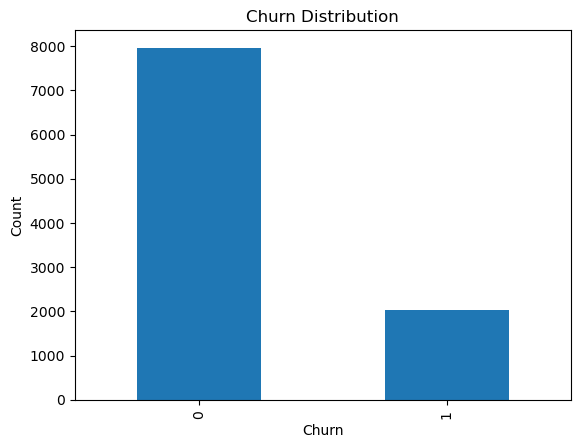

In [32]:
df["churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()


Define features and target

In [33]:
# customer_id is removed because it is only an identifier
X = df.drop(columns=["churn", "customer_id"])
y = df["churn"]


In [34]:
# categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


Categorical columns: ['country', 'gender']
Numerical columns: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']


Preprocessing

In [35]:
# Numerical data:
# - fill missing values with median
# - scale values
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical data:
# - fill missing values with most frequent value
# - convert text into numbers using one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])


Train-test split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (8000, 10)
Testing data shape: (2000, 10)


 Build models

In [37]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=7,
        random_state=42,
        class_weight="balanced"
    )
}

 Train and evaluate models

In [44]:
results = []

for model_name, model in models.items():
    # Create pipeline: preprocessing + model
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train model
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append([model_name, accuracy, precision, recall, f1, roc_auc])

# Results table
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"
])

results_df = results_df.sort_values(by="F1 Score", ascending=False)

print("\nModel Comparison:")
display(results_df)


Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Random Forest,0.8085,0.521277,0.722359,0.605561,0.859116
1,Decision Tree,0.8560,0.787440,0.400491,0.530945,0.842254
0,Logistic Regression,0.7135,0.387228,0.700246,0.498688,0.777165


Train final best model

In [45]:

#  Train final best model

final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=7,
        random_state=42,
        class_weight="balanced"
    ))
])

final_model.fit(X_train, y_train)

# predictions
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

Final model evaluation

In [46]:
print("Final Model: Random Forest")
print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

Final Model: Random Forest
Accuracy : 0.8085
Precision: 0.5212765957446809
Recall   : 0.7223587223587223
F1 Score : 0.6055612770339855
ROC AUC  : 0.859116435387622

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.83      0.87      1593
           1       0.52      0.72      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



Confusion Matrix

Confusion Matrix:
[[1323  270]
 [ 113  294]]


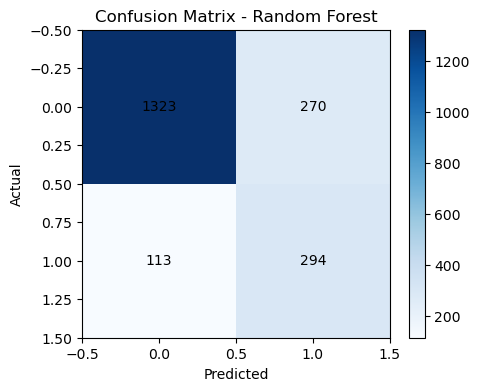

In [47]:
cm = confusion_matrix(y_test, y_pred_final)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [48]:
best_model_name = "Random Forest"
print("Final Selected Model:", best_model_name)

Final Selected Model: Random Forest


In this project, three machine learning models were trained and compared for predicting customer churn: Logistic Regression, Decision Tree, and Random Forest. Although Decision Tree achieved the highest accuracy, it had low recall, meaning it failed to identify many customers who were actually likely to churn. Random Forest gave the best overall performance with the highest F1-score and ROC-AUC, along with strong recall. Therefore, Random Forest was selected as the final model for customer churn prediction.